# M6 Interactive Demo Notebook  
## Gaming Behavior & Academic Performance Prediction

**M6 requirement:** Working demo / deployment  
**Demo type:** Interactive notebook + recorded walkthrough  

---

## What this notebook demonstrates

This notebook is designed as the **working demo** for M6.  
It allows users to interactively change a student's gaming, study, sleep, attendance, addiction, and stress-related variables, then generate a predicted academic performance score.

The demo includes:

1. Loading the processed dataset from M2/M3
2. Applying the modelling decisions from M5
3. Training the final demo model
4. Interactive sliders/dropdowns for user input
5. A predicted grade output
6. Scenario comparison
7. A gaming-hours what-if curve
8. A responsible-use statement


## 0. Setup

Run the following cell first.  
If `ipywidgets` is missing, install it with:

In [26]:
!pip uninstall ipywidgets jupyterlab_widgets -y

Found existing installation: ipywidgets 7.8.5
Uninstalling ipywidgets-7.8.5:
  Successfully uninstalled ipywidgets-7.8.5
Found existing installation: jupyterlab_widgets 1.1.11
Uninstalling jupyterlab_widgets-1.1.11:
  Successfully uninstalled jupyterlab_widgets-1.1.11


In [27]:
!pip install "ipywidgets>=8,<9" "jupyterlab_widgets>=3,<4"

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

  Attempting uninstall: widgetsnbextension

    Found existing installation: widgetsnbextension 3.6.10

    Uninstalling widgetsnbextension-3.6.10:

      Successfully uninstalled widgetsnbextension-3.6.10

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In VS Code or Jupyter Notebook, restart the kernel after installation.

In [2]:
#Imports and configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

RANDOM_STATE = 42

# Try multiple possible paths so the notebook works in different repo layouts.
DATA_DIR_CANDIDATES = [
    '../../data/processed/',
    '../data/processed/',
    'data/processed/',
    './',
    '/mnt/data/'
]

OUTPUT_DIR = 'm6_interactive_demo_outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Widgets are used for the interactive demo.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, Markdown
    WIDGETS_AVAILABLE = True
except Exception as e:
    WIDGETS_AVAILABLE = False
    print('ipywidgets is not available.')
    print('Install it with: pip install ipywidgets')
    print('Error:', e)

## 1. Load processed data

This demo uses the cleaned and processed data from earlier milestones.

Expected files:

- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`

The target variable is `grades`, so this is a regression demo.

In [3]:
#Load processed data
def find_data_dir(candidate_dirs):
    required_files = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']

    for folder in candidate_dirs:
        if all(os.path.exists(os.path.join(folder, file)) for file in required_files):
            return folder

    raise FileNotFoundError(
        'Could not find processed data files. Please check DATA_DIR_CANDIDATES.'
    )


def read_target(path):
    y_df = pd.read_csv(path)
    y_df = y_df.drop(columns=[c for c in y_df.columns if c.startswith('Unnamed')], errors='ignore')

    if 'grades' in y_df.columns:
        return y_df['grades'].astype(float)

    if y_df.shape[1] == 1:
        return y_df.iloc[:, 0].astype(float)

    raise ValueError(f'Cannot identify target column in {path}. Columns: {list(y_df.columns)}')


def clean_feature_frame(df):
    df = df.copy()
    df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
    df = df.drop(columns=['student_id'], errors='ignore')

    for col in df.select_dtypes(include=['bool']).columns:
        df[col] = df[col].astype(int)

    return df


DATA_DIR = find_data_dir(DATA_DIR_CANDIDATES)
print(f'Using processed data directory: {DATA_DIR}')

X_train_raw = clean_feature_frame(pd.read_csv(DATA_DIR + 'X_train.csv'))
X_test_raw = clean_feature_frame(pd.read_csv(DATA_DIR + 'X_test.csv'))

y_train = read_target(DATA_DIR + 'y_train.csv')
y_test = read_target(DATA_DIR + 'y_test.csv')

# Align columns.
X_train_raw = X_train_raw[[c for c in X_train_raw.columns if c in X_test_raw.columns]]
X_test_raw = X_test_raw[X_train_raw.columns]

print(f'X_train shape: {X_train_raw.shape}')
print(f'X_test shape: {X_test_raw.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train_raw.head()

Using processed data directory: ../../data/processed/
X_train shape: (6400, 20)
X_test shape: (1600, 20)
y_train shape: (6400,)
y_test shape: (1600,)


,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,gender_Male,gender_Other,genre_Casual,genre_FPS,genre_RPG,stress_level_ord,gaming_hours_sq,gaming_hours_x_FPS,gaming_hours_x_RPG,gaming_study_ratio,total_load
0,22,2.31,4.46,7.81,98.29,3.68,7.60,288.18,4.17,0,0,1,0,0,1,5.3361,0.00,0.0,0.516779,6.77
1,21,4.99,3.45,5.82,90.59,3.01,9.93,254.85,12.71,1,0,0,1,0,1,24.9001,4.99,0.0,1.442197,8.44
2,21,7.14,7.64,8.97,87.22,0.30,9.37,225.75,14.05,0,0,0,1,0,0,50.9796,7.14,0.0,0.933333,14.78
3,19,3.52,9.59,7.16,84.28,4.61,5.31,276.24,7.44,0,0,1,0,0,1,12.3904,0.00,0.0,0.366667,13.11
4,16,0.76,1.52,6.42,70.51,1.17,5.98,310.51,6.39,1,0,0,1,0,1,0.5776,0.76,0.0,0.496732,2.28


## 2. Apply M5 modelling decisions

The interactive demo follows the same modelling logic from M5:

1. Exclude `reaction_time_ms` because it may introduce leakage or mechanical-generation risk.
2. Add EDA-informed gaming threshold features:
   - `gaming_within_2h`
   - `gaming_over_2h`
   - `gaming_over_1_5h`
   - `gaming_over_2_5h`

These threshold features allow the model to reflect the EDA finding that academic performance may decline more clearly after higher gaming levels.

In [4]:
#2. Apply modelling decisions from M5
def add_threshold_features(df):
    df = df.copy()

    if 'gaming_hours' in df.columns:
        df['gaming_within_2h'] = np.minimum(df['gaming_hours'], 2.0)
        df['gaming_over_2h'] = np.maximum(0, df['gaming_hours'] - 2.0)
        df['gaming_over_1_5h'] = np.maximum(0, df['gaming_hours'] - 1.5)
        df['gaming_over_2_5h'] = np.maximum(0, df['gaming_hours'] - 2.5)

    return df


LEAKAGE_RISK_FEATURES = ['reaction_time_ms']

X_train = X_train_raw.drop(columns=LEAKAGE_RISK_FEATURES, errors='ignore')
X_test = X_test_raw.drop(columns=LEAKAGE_RISK_FEATURES, errors='ignore')

X_train = add_threshold_features(X_train)
X_test = add_threshold_features(X_test)

feature_columns = X_train.columns.tolist()

print(f'Final demo feature count: {len(feature_columns)}')
print('Excluded features:', LEAKAGE_RISK_FEATURES)
print('Threshold features:', [c for c in feature_columns if 'gaming_over' in c or 'gaming_within' in c])

Final demo feature count: 23
Excluded features: ['reaction_time_ms']
Threshold features: ['gaming_within_2h', 'gaming_over_2h', 'gaming_over_1_5h', 'gaming_over_2_5h']


## 3. Train the final demo model

For the working demo, we use **Gradient Boosting Regressor** because it was the strongest-performing model in M5.

It is suitable for this project because:

- the data is structured/tabular,
- relationships may be nonlinear,
- gaming effects may involve thresholds or interactions.

In [5]:
#Train final demo model
final_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=RANDOM_STATE
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Final demo model performance on held-out test set')
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'R²:   {r2:.3f}')

Final demo model performance on held-out test set
RMSE: 5.60
MAE:  4.42
R²:   0.936


## 4. Prediction helper functions

These functions convert user input into a model-ready student profile.

They update:

- numeric behavioural variables,
- gender and game-genre dummy variables,
- threshold features,
- interaction features created during preprocessing.

In [6]:
#Prediction helper functions
def make_base_student():
    """Start from the median training profile so every required feature exists."""
    return X_train.median(numeric_only=True).copy()


def set_category_features(row, gender='Male', genre='Casual'):
    """Update one-hot encoded gender and game genre features if they exist."""
    row = row.copy()

    # Reset known dummy variables to 0.
    for col in ['gender_Male', 'gender_Other', 'genre_Casual', 'genre_FPS', 'genre_RPG']:
        if col in row.index:
            row[col] = 0

    # Female is the reference group if no gender dummy is active.
    if gender == 'Male' and 'gender_Male' in row.index:
        row['gender_Male'] = 1
    elif gender == 'Other' and 'gender_Other' in row.index:
        row['gender_Other'] = 1

    # Genre dummies.
    if genre == 'Casual' and 'genre_Casual' in row.index:
        row['genre_Casual'] = 1
    elif genre == 'FPS' and 'genre_FPS' in row.index:
        row['genre_FPS'] = 1
    elif genre == 'RPG' and 'genre_RPG' in row.index:
        row['genre_RPG'] = 1

    return row


def update_derived_features(row):
    """Update engineered features after changing input values."""
    row = row.copy()

    if 'gaming_hours' in row.index:
        gh = float(row['gaming_hours'])

        if 'gaming_hours_sq' in row.index:
            row['gaming_hours_sq'] = gh ** 2

        if 'gaming_within_2h' in row.index:
            row['gaming_within_2h'] = min(gh, 2.0)
        if 'gaming_over_2h' in row.index:
            row['gaming_over_2h'] = max(0, gh - 2.0)
        if 'gaming_over_1_5h' in row.index:
            row['gaming_over_1_5h'] = max(0, gh - 1.5)
        if 'gaming_over_2_5h' in row.index:
            row['gaming_over_2_5h'] = max(0, gh - 2.5)

        if 'study_hours' in row.index:
            sh = float(row['study_hours'])

            if 'gaming_study_ratio' in row.index:
                row['gaming_study_ratio'] = gh / (sh + 0.01)
            if 'total_load' in row.index:
                row['total_load'] = gh + sh

        if 'genre_FPS' in row.index and 'gaming_hours_x_FPS' in row.index:
            row['gaming_hours_x_FPS'] = gh * row['genre_FPS']
        if 'genre_RPG' in row.index and 'gaming_hours_x_RPG' in row.index:
            row['gaming_hours_x_RPG'] = gh * row['genre_RPG']

        if 'device_usage' in row.index:
            row['device_usage'] = max(float(row['device_usage']), gh)

    return row


def predict_student_grade(
    age=20,
    gender='Male',
    gaming_hours=2.0,
    study_hours=4.0,
    sleep_hours=7.0,
    attendance=85.0,
    gaming_genre='Casual',
    social_activity=2.0,
    device_usage=5.0,
    addiction_score=4.0,
    stress_level_ord=1
):
    """Predict academic performance for one hypothetical student."""

    row = make_base_student()

    updates = {
        'age': age,
        'gaming_hours': gaming_hours,
        'study_hours': study_hours,
        'sleep_hours': sleep_hours,
        'attendance': attendance,
        'social_activity': social_activity,
        'device_usage': device_usage,
        'addiction_score': addiction_score,
        'stress_level_ord': stress_level_ord
    }

    for col, value in updates.items():
        if col in row.index:
            row[col] = value

    row = set_category_features(row, gender=gender, genre=gaming_genre)
    row = update_derived_features(row)

    X_one = pd.DataFrame([row])[feature_columns]
    prediction = final_model.predict(X_one)[0]

    return prediction, X_one


def grade_band(prediction):
    """Convert predicted grade into a simple stakeholder-friendly band."""
    if prediction >= 80:
        return 'High predicted performance'
    elif prediction >= 60:
        return 'Moderate predicted performance'
    else:
        return 'Academic risk zone'

## 5. Interactive prediction demo

Run the cell below to display the interactive demo.

You can adjust the sliders and dropdown menus, then click **Predict Grade**.

In [7]:
#Interactive prediction widget
if not WIDGETS_AVAILABLE:
    print('ipywidgets is not available. Please install it with: pip install ipywidgets')
else:
    age_slider = widgets.IntSlider(value=20, min=15, max=30, step=1, description='Age')
    gender_dropdown = widgets.Dropdown(
        options=['Female', 'Male', 'Other'],
        value='Male',
        description='Gender'
    )
    genre_dropdown = widgets.Dropdown(
        options=['Casual', 'FPS', 'RPG'],
        value='Casual',
        description='Genre'
    )

    gaming_slider = widgets.FloatSlider(value=2.0, min=0.0, max=10.0, step=0.5, description='Gaming h')
    study_slider = widgets.FloatSlider(value=4.0, min=0.0, max=10.0, step=0.5, description='Study h')
    sleep_slider = widgets.FloatSlider(value=7.0, min=3.0, max=12.0, step=0.5, description='Sleep h')
    attendance_slider = widgets.FloatSlider(value=85.0, min=0.0, max=100.0, step=1.0, description='Attend %')
    social_slider = widgets.FloatSlider(value=2.0, min=0.0, max=8.0, step=0.5, description='Social h')
    device_slider = widgets.FloatSlider(value=5.0, min=0.0, max=16.0, step=0.5, description='Device h')
    addiction_slider = widgets.FloatSlider(value=4.0, min=0.0, max=10.0, step=0.5, description='Addiction')
    stress_dropdown = widgets.Dropdown(
        options=[('Low', 0), ('Medium', 1), ('High', 2)],
        value=1,
        description='Stress'
    )

    predict_button = widgets.Button(description='Predict Grade', button_style='success')
    output_area = widgets.Output()

    def on_predict_clicked(button):
        with output_area:
            clear_output()

            pred, profile = predict_student_grade(
                age=age_slider.value,
                gender=gender_dropdown.value,
                gaming_hours=gaming_slider.value,
                study_hours=study_slider.value,
                sleep_hours=sleep_slider.value,
                attendance=attendance_slider.value,
                gaming_genre=genre_dropdown.value,
                social_activity=social_slider.value,
                device_usage=device_slider.value,
                addiction_score=addiction_slider.value,
                stress_level_ord=stress_dropdown.value
            )

            band = grade_band(pred)

            display(Markdown(f'## Predicted Grade: **{pred:.2f}**'))
            display(Markdown(f'### Prediction Band: **{band}**'))

            summary = pd.DataFrame([{
                'age': age_slider.value,
                'gender': gender_dropdown.value,
                'gaming_genre': genre_dropdown.value,
                'gaming_hours': gaming_slider.value,
                'study_hours': study_slider.value,
                'sleep_hours': sleep_slider.value,
                'attendance': attendance_slider.value,
                'social_activity': social_slider.value,
                'device_usage': device_slider.value,
                'addiction_score': addiction_slider.value,
                'stress_level': stress_dropdown.label,
                'predicted_grade': pred,
                'prediction_band': band
            }])

            display(summary)

            print('\nResponsible interpretation:')
            print('This prediction is a statistical estimate, not a causal judgment.')
            print('It should be used for discussion and awareness, not punishment.')

    predict_button.on_click(on_predict_clicked)

    controls_left = widgets.VBox([age_slider, gender_dropdown, genre_dropdown, gaming_slider, study_slider, sleep_slider])
    controls_right = widgets.VBox([attendance_slider, social_slider, device_slider, addiction_slider, stress_dropdown, predict_button])

    display(widgets.HBox([controls_left, controls_right]))
    display(output_area)

Output()

## 6. Scenario comparison

This section compares three example student profiles.  
It helps stakeholders understand how the model behaves across different behavioural patterns.

In [13]:
#Scenario comparison
scenarios = [
    {
        'Scenario': 'Balanced student',
        'gaming_hours': 1.5,
        'study_hours': 4.5,
        'sleep_hours': 7.5,
        'attendance': 90,
        'addiction_score': 3.0,
        'stress_level_ord': 1,
        'gaming_genre': 'Casual'
    },
    {
        'Scenario': 'High gaming, low study',
        'gaming_hours': 6.0,
        'study_hours': 1.5,
        'sleep_hours': 6.0,
        'attendance': 70,
        'addiction_score': 7.5,
        'stress_level_ord': 2,
        'gaming_genre': 'FPS'
    },
    {
        'Scenario': 'High study, moderate gaming',
        'gaming_hours': 2.5,
        'study_hours': 6.0,
        'sleep_hours': 7.0,
        'attendance': 92,
        'addiction_score': 4.0,
        'stress_level_ord': 1,
        'gaming_genre': 'RPG'
    }
]

scenario_results = []

for scenario in scenarios:
    pred, _ = predict_student_grade(
        gaming_hours=scenario['gaming_hours'],
        study_hours=scenario['study_hours'],
        sleep_hours=scenario['sleep_hours'],
        attendance=scenario['attendance'],
        addiction_score=scenario['addiction_score'],
        stress_level_ord=scenario['stress_level_ord'],
        gaming_genre=scenario['gaming_genre']
    )

    scenario_results.append({
        **scenario,
        'Predicted Grade': pred,
        'Prediction Band': grade_band(pred)
    })

scenario_df = pd.DataFrame(scenario_results)
scenario_df

,Scenario,gaming_hours,study_hours,sleep_hours,attendance,addiction_score,stress_level_ord,gaming_genre,Predicted Grade,Prediction Band
0,Balanced student,1.5,4.5,7.5,90,3.0,1,Casual,85.898587,High predicted performance
1,"High gaming, low study",6.0,1.5,6.0,70,7.5,2,FPS,25.687070,Academic risk zone
2,"High study, moderate gaming",2.5,6.0,7.0,92,4.0,1,RPG,84.525251,High predicted performance


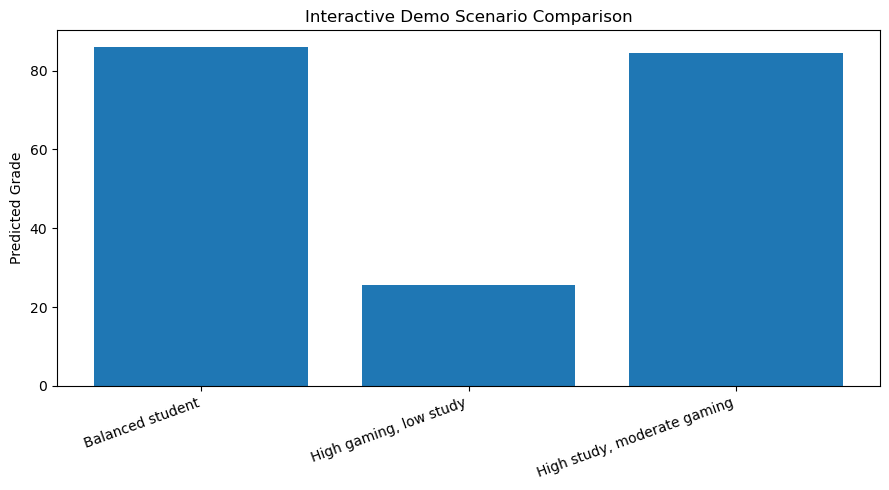

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(scenario_df['Scenario'], scenario_df['Predicted Grade'])
plt.ylabel('Predicted Grade')
plt.title('Interactive Demo Scenario Comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'scenario_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. What-if analysis: gaming hours curve

This visualisation keeps other variables constant and changes only gaming hours.

It directly addresses the project question about gaming-study balance.

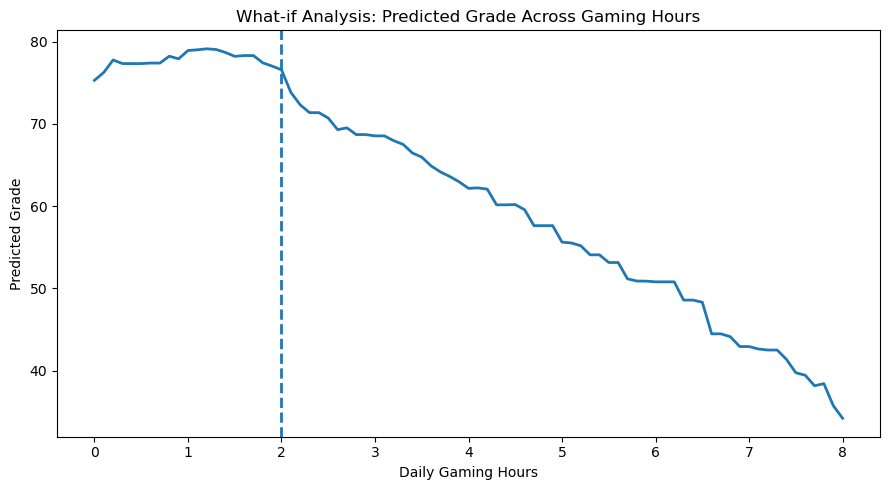

,gaming_hours,predicted_grade
0,0.0,75.306308
1,0.1,76.263699
2,0.2,77.778671
3,0.3,77.340775
4,0.4,77.340775


In [15]:
#What-if gaming-hours curve
gaming_grid = np.linspace(0, 8, 81)
curve_rows = []

for gh in gaming_grid:
    pred, _ = predict_student_grade(
        gaming_hours=gh,
        study_hours=4.0,
        sleep_hours=7.0,
        attendance=85.0,
        addiction_score=4.0,
        stress_level_ord=1,
        gaming_genre='Casual'
    )

    curve_rows.append({
        'gaming_hours': gh,
        'predicted_grade': pred
    })

curve_df = pd.DataFrame(curve_rows)

plt.figure(figsize=(9, 5))
plt.plot(curve_df['gaming_hours'], curve_df['predicted_grade'], linewidth=2)
plt.axvline(2, linestyle='--', linewidth=2)
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Predicted Grade')
plt.title('What-if Analysis: Predicted Grade Across Gaming Hours')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'gaming_hours_what_if_curve.png', dpi=200, bbox_inches='tight')
plt.show()

curve_df.head()

## 8. Responsible use statement

The model is intended to support educational discussion and awareness, not high-stakes decision-making.

This interactive demo predicts academic performance from behavioural and health-related variables.

It should be used as an educational decision-support tool, not as an automatic decision system.

The model output should not be used to punish students, label students permanently, or make high-stakes decisions.

The predictions show statistical associations learned from the dataset and do not prove causality.
